# Economic Trends Analysis

**Question:** How have inflation, unemployment, and interest rates moved together (or apart) over time, and what does that suggest about trade-offs policymakers face?

Data source: [FRED](https://fred.stlouisfed.org/) (Federal Reserve Economic Data)

Run `src/fetch_data.py` and `src/process_data.py` before this notebook.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/merged.csv", parse_dates=["date"])
df.tail()

,date,gdp,unemployment_rate,cpi,fed_funds_rate,gdp_yoy_pct,cpi_yoy_pct,unemployment_rate_3m_avg
794,2026-03-31,31865.721,4.3,330.293,3.64,6.070172,3.285958,4.333333
795,2026-04-30,32475.210,4.3,332.407,3.64,6.525942,3.779246,4.333333
796,2026-05-31,NaN,4.3,333.979,3.63,NaN,4.166615,4.300000
797,2026-06-30,NaN,4.2,332.568,3.63,NaN,3.463531,4.266667
798,2026-07-31,NaN,4.1,NaN,3.63,NaN,NaN,4.200000


## 1. Overview: what does each indicator look like over time?

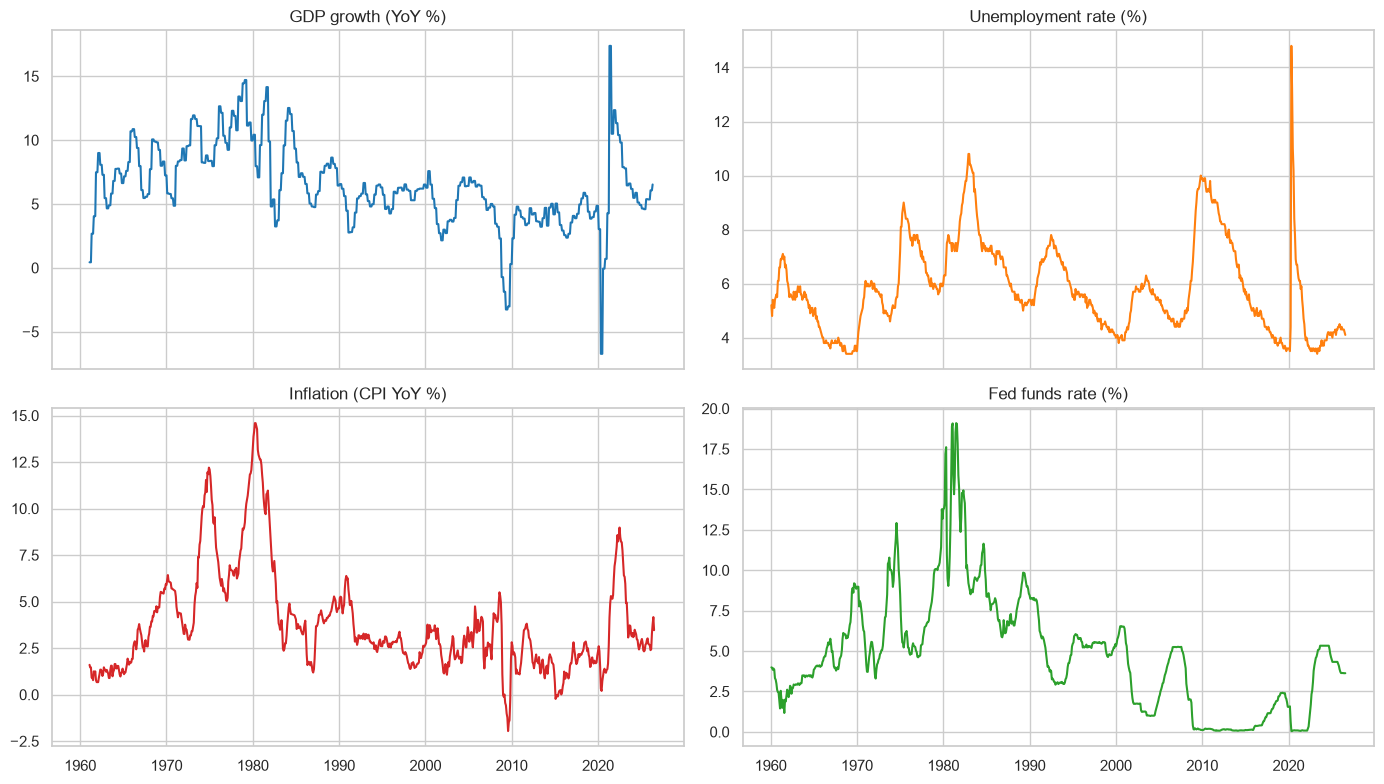

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

axes[0, 0].plot(df["date"], df["gdp_yoy_pct"], color="tab:blue")
axes[0, 0].set_title("GDP growth (YoY %)")

axes[0, 1].plot(df["date"], df["unemployment_rate"], color="tab:orange")
axes[0, 1].set_title("Unemployment rate (%)")

axes[1, 0].plot(df["date"], df["cpi_yoy_pct"], color="tab:red")
axes[1, 0].set_title("Inflation (CPI YoY %)")

axes[1, 1].plot(df["date"], df["fed_funds_rate"], color="tab:green")
axes[1, 1].set_title("Fed funds rate (%)")

plt.tight_layout()
plt.show()

## 2. Inflation vs. unemployment (the Phillips Curve question)

Classic macro tension: does lower unemployment tend to come with higher inflation?

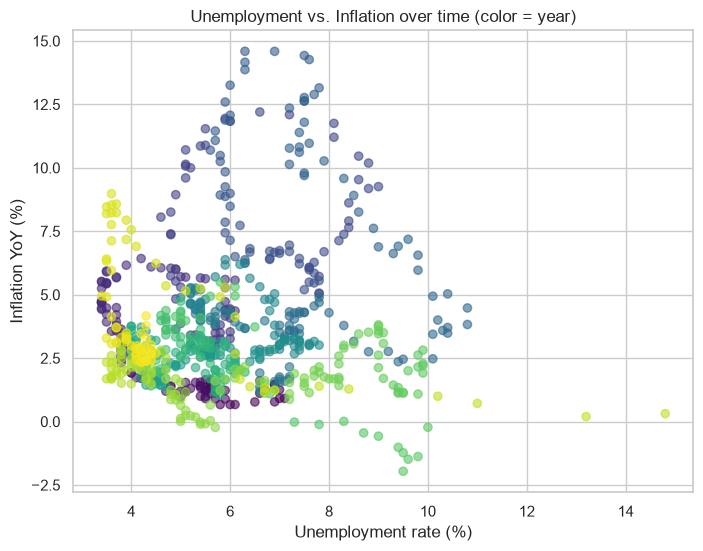

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    df["unemployment_rate"],
    df["cpi_yoy_pct"],
    c=df["date"].astype("int64"),
    cmap="viridis",
    alpha=0.6,
)
ax.set_xlabel("Unemployment rate (%)")
ax.set_ylabel("Inflation YoY (%)")
ax.set_title("Unemployment vs. Inflation over time (color = year)")
plt.show()

## 3. Correlation matrix

Quantify how strongly these indicators move together.

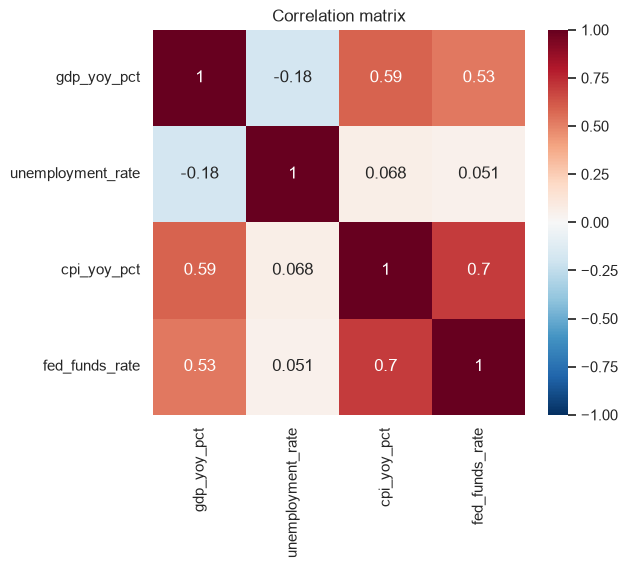

In [5]:
corr_cols = ["gdp_yoy_pct", "unemployment_rate", "cpi_yoy_pct", "fed_funds_rate"]
corr = df[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.savefig("../docs/correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Fed funds rate response to inflation

Does the Fed raise rates in response to rising inflation? Plot both on the same timeline.

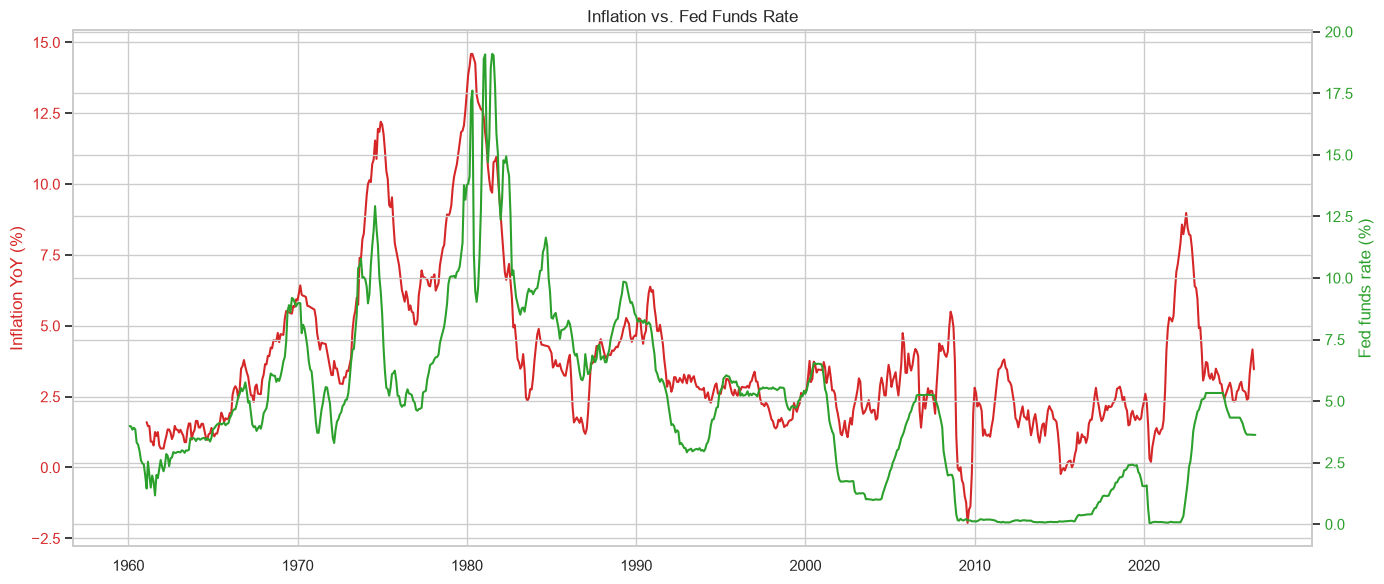

In [4]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df["date"], df["cpi_yoy_pct"], color="tab:red", label="Inflation (YoY %)")
ax1.set_ylabel("Inflation YoY (%)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

ax2 = ax1.twinx()
ax2.plot(df["date"], df["fed_funds_rate"], color="tab:green", label="Fed funds rate (%)")
ax2.set_ylabel("Fed funds rate (%)", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")

plt.title("Inflation vs. Fed Funds Rate")
fig.tight_layout()
plt.savefig("../docs/inflation_vs_fedfunds.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Findings

1. The Fed responds to inflation more than to unemployment — and the correlation confirms it. CPI inflation and the fed funds rate have a 0.70 correlation, the strongest pairwise relationship in the matrix. The overlay chart shows this plainly: every major inflation peak (1974, 1980, 2022) is followed by the Fed pushing rates up aggressively, most dramatically the ~19% federal funds rate under Volcker in the early 1980s used to break double-digit inflation. By contrast, unemployment's correlation with the fed funds rate is essentially zero (0.051) — rate policy tracks prices, not joblessness, at least at this correlation-level view.

2. Unemployment is nearly uncorrelated with inflation over the full 60-year span (0.068). This is a genuinely counterintuitive result if you walked in expecting a clean Phillips Curve trade-off. It's not that the relationship doesn't exist — it's that it flips sign across different eras (as the scatter plot showed: stagflation-era co-movement vs. tight-labor-market-with-inflation in 2021-22), so those opposing periods cancel out in a single full-sample correlation. This is a good example of why aggregate correlation can hide regime-dependent relationships.

3. GDP growth has a moderate negative relationship with unemployment (-0.18) and positive relationships with both inflation (0.59) and the fed funds rate (0.53). The GDP panel makes the mechanism visible: the sharp 2020 COVID collapse (GDP growth diving toward -8%) coincides with unemployment spiking to nearly 15% — the single most extreme point in the entire dataset — while the snap-back growth surge afterward (~17%) lines up with the 2021-22 inflation spike and the Fed's subsequent rate hikes.

4. Two distinct crisis "signatures" stand out in the time series. The 2008-09 financial crisis shows the fed funds rate cut essentially to zero and held there for years while unemployment climbed slowly to ~10% and stayed elevated — a demand-driven, slow-recovery pattern. 2020 shows the opposite shape: unemployment spiked and recovered fast, GDP cratered and rebounded within a year, and inflation didn't follow until 2021-22 — a supply-chain and stimulus-driven pattern rather than a classic recession.

5. Overall, the strongest, most consistent relationship in 60+ years of data is monetary policy tracking inflation (0.70), not unemployment. The unemployment-inflation trade-off that motivates a lot of introductory macro teaching is much weaker and far more era-dependent than the Fed's reaction function to prices.

A note on the 2020 outlier: The COVID period (2020) shows GDP growth swinging from roughly -8% to +17% within about a year, alongside unemployment spiking to nearly 15% — both are the most extreme values in the entire 60+ year dataset by a wide margin. Because Pearson correlation is sensitive to outliers, this single episode could be pulling some of the correlations above (particularly gdp_yoy_pct's relationships with the other variables) higher or lower than what the more "typical" historical relationship looks like.

A useful follow-up check: re-run the correlation matrix excluding 2020-2021, and compare. If the correlations shift meaningfully, that tells you the 2020 shock is doing a lot of the work — worth calling out explicitly rather than treating all 60+ years as one uniform regime. If they hold roughly steady, that's reassuring evidence the relationships are structural rather than driven by one event.

In [ ]:
# quick way to test this in the notebook
df_excl_covid = df[~df["date"].between("2020-01-01", "2021-12-31")]
corr_excl = df_excl_covid[corr_cols].corr()

## Next steps

- Add NBER recession shading to highlight downturns
- Try a simple forecasting model (ARIMA/Prophet) on one series
- Compare against another country's indicators